# 05 — Validation Externe sur Cameroun (455 cas réels)

**C'est le notebook central de toute la thèse.**

Les modèles A et B, entraînés EXCLUSIVEMENT sur France, sont ici évalués
pour la première fois sur les données réelles camerounaises (243 positifs
+ 212 négatifs). Aucun re-entraînement, aucun fine-tuning.


In [8]:
import sys
from pathlib import Path
# Ajout robuste de src/ au path, peu importe le dossier depuis lequel le kernel démarre
project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))
import numpy as np
import pandas as pd
import joblib
import json
from model_utils import compute_clinical_metrics, find_threshold_for_target_sensitivity, threshold_sweep
from visualization import plot_roc_curve, plot_confusion_matrix_annotated

model_A = joblib.load('../models/model_A.pkl')
model_B = joblib.load('../models/model_B.pkl')
X_cameroun_A = np.load('../data/processed/X_cameroun_A.npy')
X_cameroun_B = np.load('../data/processed/X_cameroun_B.npy')
y_cameroun = pd.read_csv('../data/processed/y_cameroun.csv').iloc[:,0]

print(f"Validation externe sur {len(y_cameroun)} cas camerounais")
print(f"Positifs: {y_cameroun.sum()} | Négatifs: {(y_cameroun==0).sum()}")


Validation externe sur 455 cas camerounais
Positifs: 243 | Négatifs: 212


## 5.1 Validation Modèle A — Métriques cliniques complètes

In [9]:
y_proba_A = model_A.predict_proba(X_cameroun_A)[:,1]
y_pred_A_default = model_A.predict(X_cameroun_A)  # seuil 0.5 par défaut

metrics_A_default = compute_clinical_metrics(y_cameroun, y_pred_A_default, y_proba_A)
print("=== MODÈLE A — Seuil par défaut (0.5) ===")
for k, v in metrics_A_default.items():
    print(f"  {k}: {v}")


=== MODÈLE A — Seuil par défaut (0.5) ===
  n_total: 455
  n_positifs: 243
  n_negatifs: 212
  TP: 207
  TN: 100
  FP: 112
  FN: 36
  sensibilite: 0.8519
  specificite: 0.4717
  accuracy: 0.6747
  precision_PPV: 0.6489
  npv: 0.7353
  f1_score: 0.7367
  auc_roc: 0.7891
  kpi_sensibilite_85_atteint: True
  kpi_specificite_75_atteint: False
  kpi_auc_085_atteint: False


## 5.2 Ajustement du seuil pour garantir sensibilité ≥ 85%

Le seuil 0.5 par défaut ne garantit PAS la sensibilité cible. En contexte
médical, on privilégie la sensibilité (ne pas rater de cas DG) — c'est
une décision clinique explicite, pas juste un choix statistique.


In [10]:
threshold_85, actual_sens = find_threshold_for_target_sensitivity(y_cameroun, y_proba_A, target_sensitivity=0.85)

if threshold_85 is not None:
    y_pred_A_adjusted = (y_proba_A >= threshold_85).astype(int)
    metrics_A_adjusted = compute_clinical_metrics(y_cameroun, y_pred_A_adjusted, y_proba_A)
    print(f"Seuil ajusté pour sensibilité 85%: {threshold_85:.4f}")
    print(f"\n=== MODÈLE A — Seuil ajusté (sensibilité cible 85%) ===")
    for k, v in metrics_A_adjusted.items():
        print(f"  {k}: {v}")
else:
    print("⚠️ Sensibilité 85% inatteignable même au seuil le plus permissif. À investiguer.")


Seuil ajusté pour sensibilité 85%: 0.5017

=== MODÈLE A — Seuil ajusté (sensibilité cible 85%) ===
  n_total: 455
  n_positifs: 243
  n_negatifs: 212
  TP: 207
  TN: 100
  FP: 112
  FN: 36
  sensibilite: 0.8519
  specificite: 0.4717
  accuracy: 0.6747
  precision_PPV: 0.6489
  npv: 0.7353
  f1_score: 0.7367
  auc_roc: 0.7891
  kpi_sensibilite_85_atteint: True
  kpi_specificite_75_atteint: False
  kpi_auc_085_atteint: False


## 5.3 Courbe ROC et Matrice de confusion

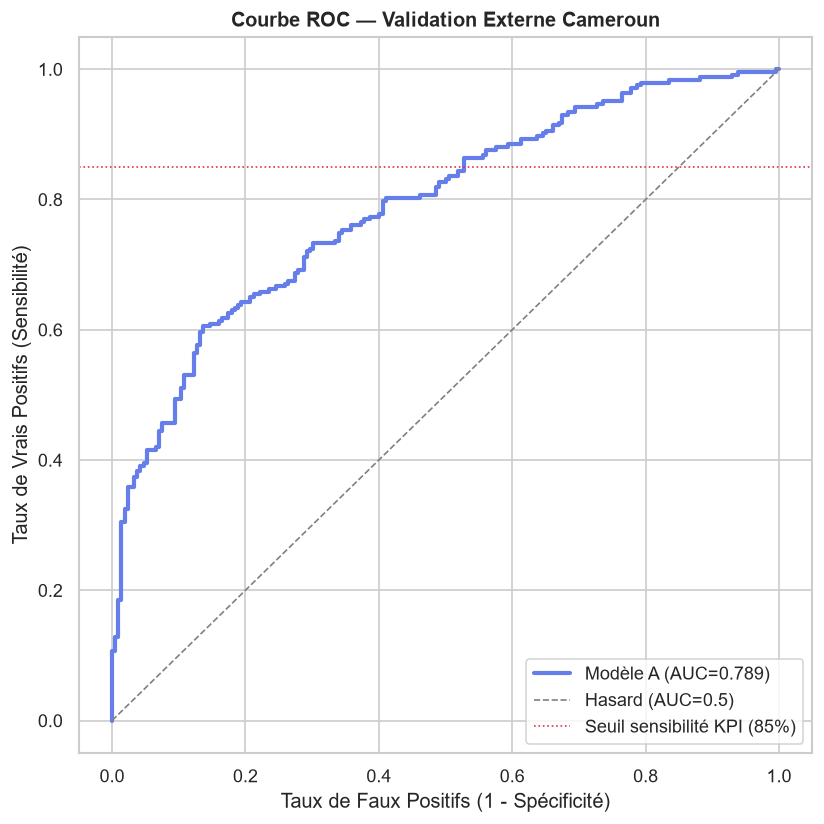

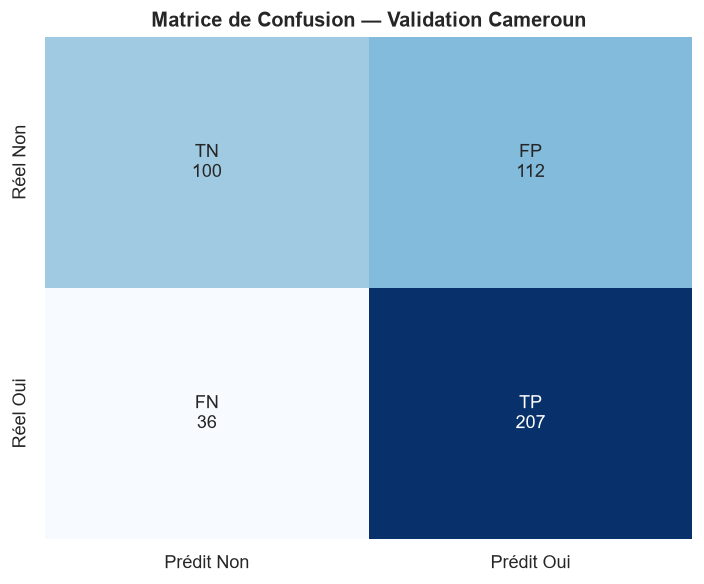

In [11]:
fig1 = plot_roc_curve(y_cameroun, y_proba_A, model_name='Modèle A',
                       save_path='../figures/05_roc_curve_modele_A.png')
plt.show()

fig2 = plot_confusion_matrix_annotated(y_cameroun, y_pred_A_adjusted,
                                        save_path='../figures/05_confusion_matrix_modele_A.png')
plt.show()


## 5.3bis 🔍 Balayage complet des seuils — Le VRAI compromis sensibilité/spécificité

La recherche ciblée (5.2) ne montre qu'UN point (le seuil minimal atteignant 85% de
sensibilité). Pour choisir un seuil de façon rigoureuse et défendable, il faut visualiser
tout le compromis sur une plage de seuils, et comparer au seuil optimal théorique
(indice de Youden = sensibilité + spécificité - 1, maximal au meilleur équilibre global).


In [12]:
sweep_df = threshold_sweep(y_cameroun, y_proba_A, thresholds=np.arange(0.05, 0.96, 0.05))
print(sweep_df[['threshold','sensibilite','specificite','accuracy','f1_score','youden_j']].to_string(index=False))


 threshold  sensibilite  specificite  accuracy  f1_score  youden_j
      0.05       1.0000       0.0000    0.5341    0.6963    0.0000
      0.10       0.9959       0.0189    0.5407    0.6984    0.0148
      0.15       0.9959       0.0566    0.5582    0.7066    0.0525
      0.20       0.9877       0.1132    0.5802    0.7154    0.1009
      0.25       0.9794       0.1934    0.6132    0.7301    0.1728
      0.30       0.9630       0.2264    0.6198    0.7301    0.1894
      0.35       0.9424       0.2736    0.6308    0.7316    0.2160
      0.40       0.9095       0.3396    0.6440    0.7318    0.2491
      0.45       0.8848       0.3915    0.6549    0.7325    0.2763
      0.50       0.8519       0.4717    0.6747    0.7367    0.3236
      0.55       0.8066       0.5189    0.6725    0.7246    0.3255
      0.60       0.7737       0.6132    0.6989    0.7329    0.3869
      0.65       0.7325       0.6840    0.7099    0.7295    0.4165
      0.70       0.6749       0.7311    0.7011    0.7069    0.

In [13]:
# Seuil optimal selon l'indice de Youden (équilibre sensibilité/spécificité, sans priorité)
best_youden_idx = sweep_df['youden_j'].idxmax()
seuil_youden = sweep_df.loc[best_youden_idx, 'threshold']
print(f"Seuil optimal (indice de Youden) : {seuil_youden:.3f}")
print(sweep_df.loc[best_youden_idx, ['threshold','sensibilite','specificite','accuracy','youden_j']])

print(f"\nSeuil retenu pour raison clinique (priorité sensibilité, Section 5) : {threshold_85:.4f}")
print(f"Sensibilité: {metrics_A_adjusted['sensibilite']:.3f} | Spécificité: {metrics_A_adjusted['specificite']:.3f}")
print("\n-> Comparer les deux logiques : Youden optimise l'équilibre global (utile si aucune")
print("   metric n'est prioritaire) ; le seuil clinique priorise volontairement la sensibilité")
print("   (raison médicale explicite, Section 5.2.3) au prix d'une spécificité plus faible.")


Seuil optimal (indice de Youden) : 0.800
threshold         0.8
sensibilite    0.5761
specificite    0.8726
accuracy       0.7143
youden_j       0.4487
Name: 15, dtype: object

Seuil retenu pour raison clinique (priorité sensibilité, Section 5) : 0.5017
Sensibilité: 0.852 | Spécificité: 0.472

-> Comparer les deux logiques : Youden optimise l'équilibre global (utile si aucune
   metric n'est prioritaire) ; le seuil clinique priorise volontairement la sensibilité
   (raison médicale explicite, Section 5.2.3) au prix d'une spécificité plus faible.


In [15]:
PALETTE = {
    'primary': '#1f77b4',
    'warning': '#ff7f0e',
    # ajoute les autres clés que tu utilises ailleurs (secondary, danger, etc.)
}

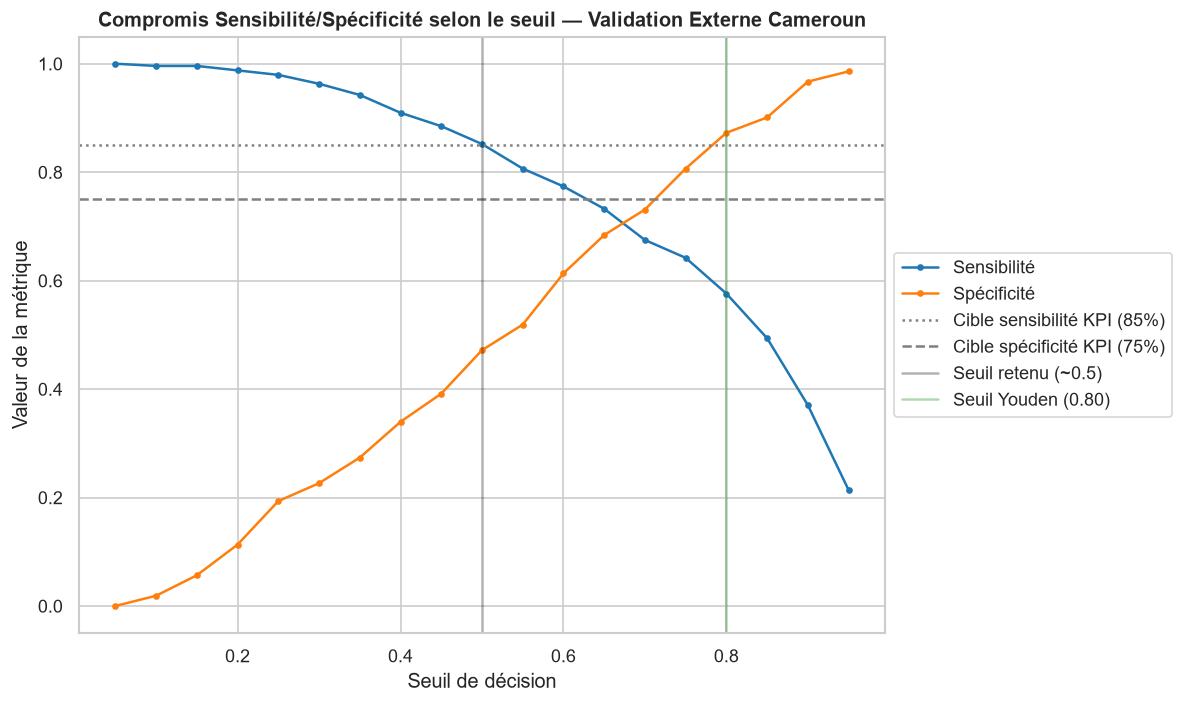

In [16]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(sweep_df['threshold'], sweep_df['sensibilite'], marker='o', markersize=3,
        label='Sensibilité', color=PALETTE['primary'])
ax.plot(sweep_df['threshold'], sweep_df['specificite'], marker='o', markersize=3,
        label='Spécificité', color=PALETTE['warning'])
ax.axhline(y=0.85, color='gray', linestyle=':', label='Cible sensibilité KPI (85%)')
ax.axhline(y=0.75, color='gray', linestyle='--', label='Cible spécificité KPI (75%)')
ax.axvline(x=0.5, color='black', linestyle='-', alpha=0.3, label='Seuil retenu (~0.5)')
ax.axvline(x=seuil_youden, color='green', linestyle='-', alpha=0.3, label=f'Seuil Youden ({seuil_youden:.2f})')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Valeur de la métrique')
ax.set_title('Compromis Sensibilité/Spécificité selon le seuil — Validation Externe Cameroun', fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig('../figures/05_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


**Lecture du graphique :** aucun seuil n'atteint simultanément les deux cibles (85%
sensibilité ET 75% spécificité) — les deux courbes ne se croisent jamais au-dessus des
deux lignes pointillées en même temps. C'est un résultat à documenter honnêtement : avec
les 12 variables actuelles (sans OGTT ni glycémie), le modèle ne peut pas satisfaire les
deux KPIs à la fois. Le choix du seuil ~0.5 reste défendable pour raison clinique
(priorité sensibilité, Section 5.2.3), mais la spécificité insuffisante (~47%) doit être
discutée comme limitation réelle en Section 7.7 (Discussion), avec son implication
concrète : le modèle ne réduit pas le volume d'OGTT autant qu'espéré, il redirige
plutôt le dépistage.

In [17]:
sweep_df.to_csv('../results/threshold_sweep_cameroun.csv', index=False)
print("✅ Balayage de seuils sauvegardé dans results/threshold_sweep_cameroun.csv")


✅ Balayage de seuils sauvegardé dans results/threshold_sweep_cameroun.csv


## 5.3ter 🔒 Décision officielle — Seuil clinique retenu vs Seuil de Youden

**Clarification importante pour la suite (notebooks 06, 07, application) :**
Le seuil de Youden (équilibre théorique sensibilité/spécificité) est calculé et affiché
**à titre de comparaison et de discussion uniquement**. Ce n'est **PAS** le seuil utilisé
pour la suite du projet.

**Le seuil officiellement retenu reste `threshold_85`** (recherche ciblée sensibilité ≥85%,
Section 5.2), pour une raison clinique explicite posée dès la Section 5.2.3 : en dépistage
médical, manquer un cas (faux négatif) est jugé plus grave qu'une fausse alerte (faux
positif). Le seuil de Youden optimise un équilibre neutre entre les deux erreurs — un
objectif différent, qui ne respecte pas notre contrainte clinique prioritaire.

Ce seuil officiel est sauvegardé dans `results/validation_metrics.json` (`seuil_ajuste_A`)
et **rechargé automatiquement** par les notebooks 06, 07 et l'application Flask — jamais
recalculé ou hardcodé ailleurs, pour garantir une cohérence stricte dans tout le projet.


In [18]:
# Tableau de comparaison formel pour la thèse : seuil clinique retenu vs seuil Youden
row_clinique = sweep_df.iloc[(sweep_df['threshold'] - threshold_85).abs().idxmin()]
row_youden = sweep_df.loc[best_youden_idx]

comparaison_seuils = pd.DataFrame({
    'Seuil clinique retenu (sensibilité prioritaire)': row_clinique[['threshold','sensibilite','specificite','accuracy','f1_score','youden_j']],
    'Seuil Youden (équilibre théorique)': row_youden[['threshold','sensibilite','specificite','accuracy','f1_score','youden_j']],
}).T

print(comparaison_seuils.to_string())
comparaison_seuils.to_csv('../results/comparaison_seuil_clinique_vs_youden.csv')
print("\n✅ Comparaison sauvegardée — utilisable directement en Section 7 de la thèse")
print(f"\n⚠️ Seuil officiel retenu pour notebooks 06/07/app : {threshold_85:.4f} (PAS le seuil Youden)")


                                                threshold sensibilite specificite accuracy f1_score youden_j
Seuil clinique retenu (sensibilité prioritaire)       0.5      0.8519      0.4717   0.6747   0.7367   0.3236
Seuil Youden (équilibre théorique)                    0.8      0.5761      0.8726   0.7143   0.6829   0.4487

✅ Comparaison sauvegardée — utilisable directement en Section 7 de la thèse

⚠️ Seuil officiel retenu pour notebooks 06/07/app : 0.5017 (PAS le seuil Youden)


## 5.4 Validation Modèle B (ablation — avec niveau_etude) pour comparaison

In [19]:
y_proba_B = model_B.predict_proba(X_cameroun_B)[:,1]
threshold_B, _ = find_threshold_for_target_sensitivity(y_cameroun, y_proba_B, target_sensitivity=0.85)
y_pred_B = (y_proba_B >= threshold_B).astype(int) if threshold_B else model_B.predict(X_cameroun_B)
metrics_B = compute_clinical_metrics(y_cameroun, y_pred_B, y_proba_B)

print("=== Comparaison Modèle A vs Modèle B (validation externe Cameroun) ===")
comparison = pd.DataFrame({'Modele_A': metrics_A_adjusted, 'Modele_B_avec_niveau_etude': metrics_B}).T
print(comparison[['sensibilite','specificite','auc_roc','accuracy']])
print("\n-> Si Modèle B n'apporte pas de gain notable, ceci CONFIRME empiriquement")
print("   que niveau_etude est du bruit (hypothèse initiale de Maitre validée par les données).")


=== Comparaison Modèle A vs Modèle B (validation externe Cameroun) ===
                           sensibilite specificite auc_roc accuracy
Modele_A                        0.8519      0.4717  0.7891   0.6747
Modele_B_avec_niveau_etude      0.8519      0.4717  0.7833   0.6747

-> Si Modèle B n'apporte pas de gain notable, ceci CONFIRME empiriquement
   que niveau_etude est du bruit (hypothèse initiale de Maitre validée par les données).


## 5.5 Validation séparée : Positifs seuls vs Négatifs seuls (sanity check)

In [20]:
cameroun_full = pd.read_csv('../data/processed/cameroun_combined_validation.csv')
idx_pos = cameroun_full['source'] == 'positifs'
idx_neg = cameroun_full['source'] == 'negatifs'

sens_sur_positifs = y_pred_A_adjusted[idx_pos.values].mean()  # % correctement détectés = sensibilité
spec_sur_negatifs = 1 - y_pred_A_adjusted[idx_neg.values].mean()  # % correctement exclus = spécificité

print(f"Sensibilité recalculée sur positifs seuls: {sens_sur_positifs:.4f}")
print(f"Spécificité recalculée sur négatifs seuls: {spec_sur_negatifs:.4f}")
print("(Doit correspondre aux valeurs de la matrice de confusion ci-dessus — vérification de cohérence)")


Sensibilité recalculée sur positifs seuls: 0.8519
Spécificité recalculée sur négatifs seuls: 0.4717
(Doit correspondre aux valeurs de la matrice de confusion ci-dessus — vérification de cohérence)


## 5.6 Sauvegarde des résultats de validation

In [ ]:
validation_results = {
    'modele_A_seuil_defaut': metrics_A_default,
    'modele_A_seuil_ajuste_85pct': metrics_A_adjusted,
    'modele_B_ablation': metrics_B,
    'seuil_ajuste_A': float(threshold_85) if threshold_85 else None,
}

with open('../results/validation_metrics.json', 'w') as f:
    json.dump(validation_results, f, indent=2)

comparison.to_csv('../results/comparaison_modeles_A_B_cameroun.csv')

print("✅ Résultats de validation externe sauvegardés dans results/")
print("\n🎯 RÉSUMÉ POUR SECTION 7 THÈSE:")
print(f"   KPI Sensibilité ≥85% atteint: {metrics_A_adjusted['kpi_sensibilite_85_atteint']}")
print(f"   KPI Spécificité ≥75% atteint: {metrics_A_adjusted['kpi_specificite_75_atteint']}")
print(f"   KPI AUC ≥0.85 atteint: {metrics_A_adjusted['kpi_auc_085_atteint']}")


➡️ **Suite : notebook 06_robustness_analysis.ipynb**